### Effect of sampling frequency on log return variance
This notebook will investigate the effect sampling frequency of log returns has on the standard deviation of sampled log returns. This is relevant for Value-at-Risk models, especially long term ones which aim to capture value at risk across longer horizons than one day. For example, if the interest is in biweekly Value-at-Risk, biweekly returns can be sampled on a daily basis, weekly basis or biweekly basis. 

The research question here is - what happens to the VaR estimate if biweekly returns are sampled on a daily basis rather than on a weekly basis? Since the VaR estimate is driven by the standard deviation of the distribution, the question becomes: what effect does the sampling frequency have on the standard deviation of the sample?

To answer this question, we begin by generating an asset price series. In finance, this typically modelled as geometric brownian motion, which requires as parameters the initial asset price S0, the drift mu, the volatility sigma, the time horizon T and the number of steps N. Let's generate asset prices for 20 years with 252 trading days per year and an initial price of 100.

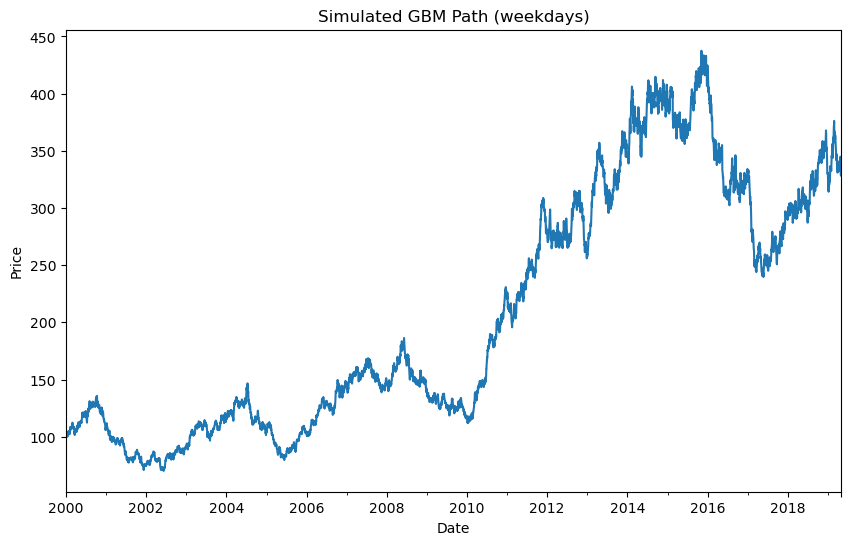

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

S0 = 100
mu = 0.1
sigma = 0.2
T = 20
N = 5040

dt = T/N

dates = pd.bdate_range(start="2000-01-01", periods=N+1)

Z = np.random.standard_normal(N)
W = np.cumsum(np.sqrt(dt) * Z)

t = np.linspace(0, T, N+1)
X = (mu -0.5 * sigma**2) *t[1:] + sigma *W
S = np.zeros(N+1)

S[0] = S0
S[1:] = S0 * np.exp(X)

df = pd.DataFrame({'Date': dates, "Price": S})
df.set_index("Date", inplace=True)

df["Price"].plot(figsize=(10,6), title="Simulated GBM Path (weekdays)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Lets first imagine a scenario where we sample the price from every Wednesday in this price series, and the calculate the biweekly log return every wednesday. Call this sample of biweekly returns weekly_biweekly. 

In [24]:
df_wed = df[df.index.weekday == 2]
weekly_biweekly = np.log(df_wed / df_wed.shift(2))
weekly_biweekly = weekly_biweekly.dropna().copy()

In the second scenario we sample the biweekly log return on every single working day. Call this df daily_biweekly. 

In [26]:
daily_biweekly = np.log(df / df.shift(10))
daily_biweekly = daily_biweekly.dropna().copy()

Weekly_biweekly contains (5040/5)-2=1008 observations and daily_biweekly contains (5040-9) = 5031 observations.  

In [27]:
print(weekly_biweekly.shape)
print(daily_biweekly.shape)

(1006, 1)
(5031, 1)


Lets plot the last three years of observations for the two samples. The first thing we can notice is that the scale and shape of the log returns are the same in both graphs. The only difference is that the daily_biweekly sample contains more observations.

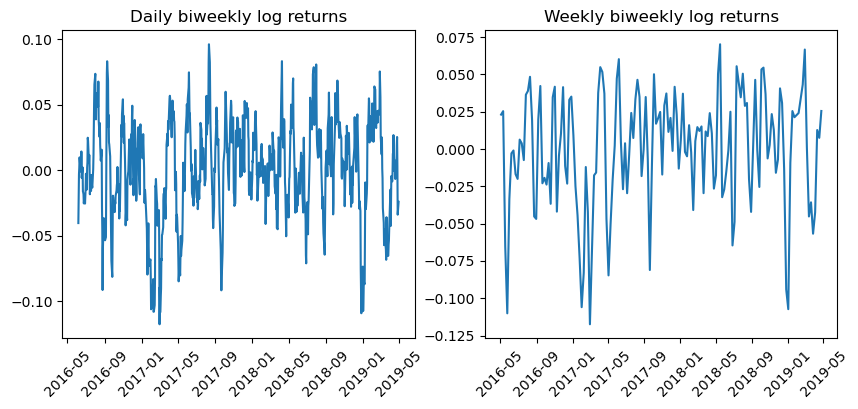

In [20]:
fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].plot(daily_biweekly[-756:])
axs[0].set_title('Daily biweekly log returns')
axs[1].plot(weekly_biweekly[-156:])
axs[1].set_title('Weekly biweekly log returns')
for ax in axs:
    ax.tick_params(axis='x', labelrotation=45)
plt.show()

With daily biweekly returns, each observation looks very similar to the previous one because they span 13 of the same 14-day period. This introduces a high degree of autocorrelation. There is autocorrelation in the weekly biweekly log returns as well, since 7 out of 14 days overlap for consecutive observations, but to a lower degree. We can measure the autocorrelation as follows.

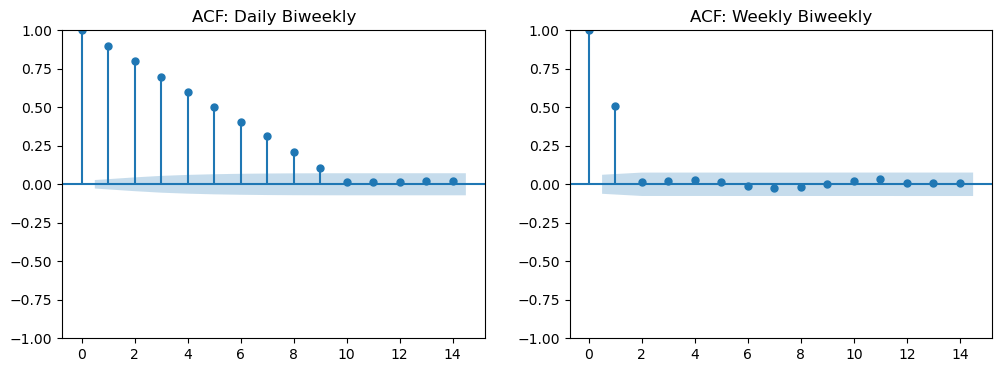

In [28]:
from statsmodels.graphics.tsaplots import plot_acf
fig, axs = plt.subplots(1,2, figsize=(12,4))
plot_acf(daily_biweekly['Price'], lags=14, ax=axs[0])
axs[0].set_title('ACF: Daily Biweekly')
plot_acf(weekly_biweekly['Price'], lags=14, ax=axs[1])
axs[1].set_title('ACF: Weekly Biweekly')
plt.show()

Does this higher level of autocorrelation cause the standard deviation of daily_biweekly to be lower than weekly_biweekly? To test this, we calculate a std values based on a rolling window spanning 1 year for each log return series and compare the average standard deviation.

In [29]:
daily_biweekly_std = daily_biweekly.rolling(52).std()
weekly_biweekly_std = weekly_biweekly.rolling(window=252).std()
print(daily_biweekly_std.mean())
print(weekly_biweekly_std.mean())

Price    0.034876
dtype: float64
Price    0.039384
dtype: float64


We can also print the average standard deviation of the entire daily_biweekly and weekly_biweekly price series.

In [30]:
print(daily_biweekly.std())
print(weekly_biweekly.std())

Price    0.039393
dtype: float64
Price    0.039389
dtype: float64


We can see that daily sampling of biweekly returns does not systematically lower the standard deviation of sampled log returns. This is because both sampling approaches reflect the underlying variance of bi-weekly log returns. 

The only difference between the two approaches is that daily sampling provides more datapoints within a given time period. However, this does not improve the confidence level of the standard deviation estimate since these extra data-points are highly autocorrelated. This correlation means you don't gain as much independent information as it looks like.

The bottom line is that using overlapping returns won't bias a VaR estimate (since the underlying retursn is the same). The only thing to be wary of is that if you don't adjust for the autocorrelation, you'll think that your estimate is based on more data than it is. 